8-Page Web Adjacency Matrix:
     A  B  C  D  E  F  G  H
A   [0. 0. 1. 1. 0. 0. 0. 0.]
B   [1. 0. 0. 0. 0. 0. 0. 0.]
C   [1. 1. 0. 0. 0. 0. 0. 0.]
D   [0. 1. 1. 0. 0. 0. 0. 0.]
E   [0. 0. 0. 1. 0. 0. 0. 0.]
F   [0. 0. 0. 0. 1. 0. 1. 0.]
G   [0. 0. 0. 0. 0. 1. 0. 0.]
H   [0. 0. 0. 1. 0. 0. 0. 0.]
Page A -> ['B', 'C'])
Page B -> ['C', 'D'])
Page C -> ['A', 'D'])
Page D -> ['A', 'E', 'H'])
Page E -> ['F'])
Page F -> ['G'])
Page G -> ['F'])
Page H -> None (dangling_node)

Dangling Nodes:['H'] - no outgoing links

Damping factor d = 0.85 applied successfully
Converged in 75 with Final error = 9.60e-07


Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.084104    |   8.41%
  B  |    0.059595    |   5.96%
  C  |    0.084924    |   8.49%
  D  |    0.085272    |   8.53%
  E  |    0.048012    |   4.80%
  F  |    0.306071    |   30.61%
  G  |    0.284011    |   28.40%
  H  |    0.048012    |   4.80%
------------------------------------------
Sum: 1.000000 (

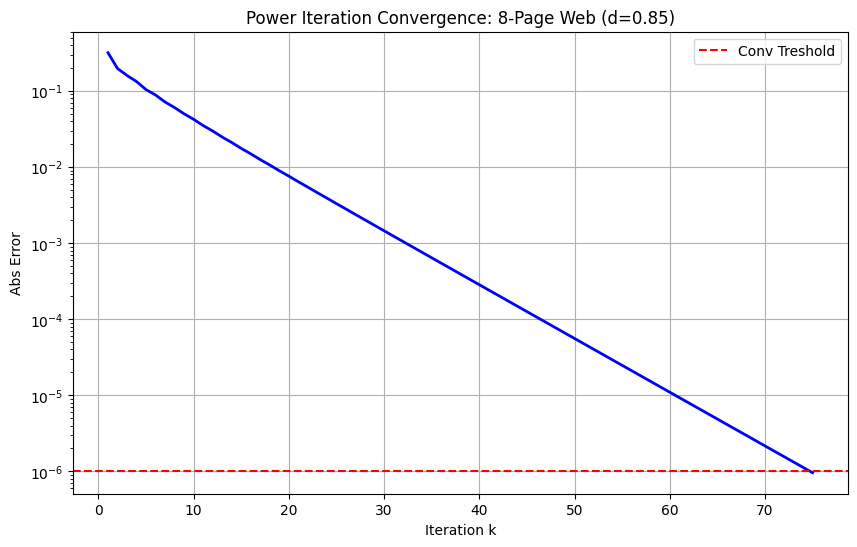

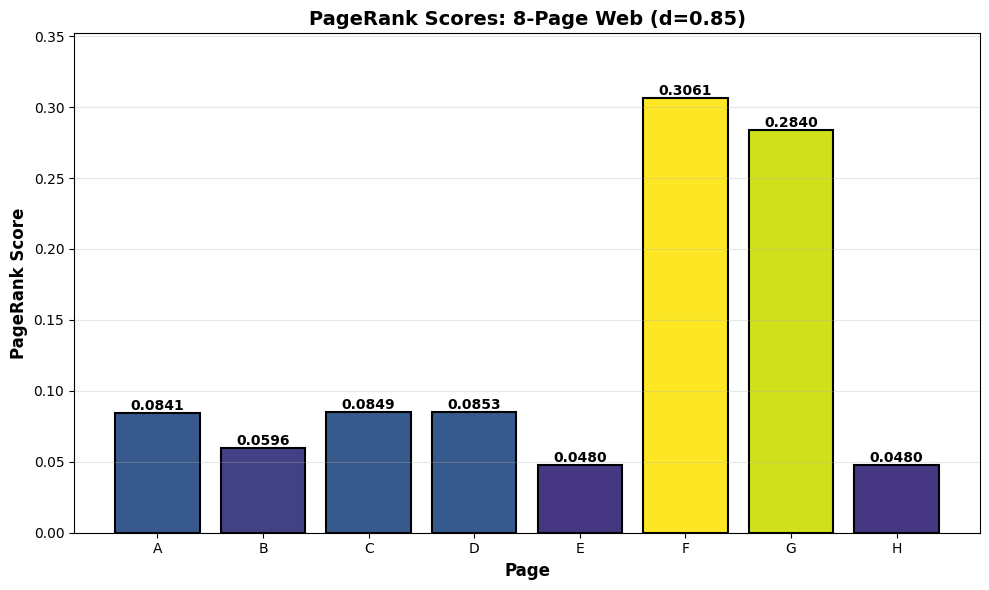

Validation Passed

[0.0841 0.0596 0.0849 0.0853 0.048  0.3061 0.284  0.048 ]
  Rank 1: Page F  -  0.306071  (30.61%)
  Rank 2: Page G  -  0.284011  (28.40%)
  Rank 3: Page D  -  0.085272  (8.53%)
  Rank 4: Page C  -  0.084924  (8.49%)
  Rank 5: Page A  -  0.084104  (8.41%)
  Rank 6: Page B  -  0.059595  (5.96%)
  Rank 7: Page E  -  0.048012  (4.80%)
  Rank 8: Page H  -  0.048012  (4.80%)
  Rank 1: Page F  -  0.306071  (30.61%)
  Rank 2: Page G  -  0.284011  (28.40%)
  Rank 3: Page D  -  0.085272  (8.53%)
  Rank 4: Page C  -  0.084924  (8.49%)
  Rank 5: Page A  -  0.084104  (8.41%)
  Rank 6: Page B  -  0.059595  (5.96%)
  Rank 7: Page E  -  0.048012  (4.80%)
  Rank 8: Page H  -  0.048012  (4.80%)
  Rank 1: Page F  -  0.306071  (30.61%)
  Rank 2: Page G  -  0.284011  (28.40%)
  Rank 3: Page D  -  0.085272  (8.53%)
  Rank 4: Page C  -  0.084924  (8.49%)
  Rank 5: Page A  -  0.084104  (8.41%)
  Rank 6: Page B  -  0.059595  (5.96%)
  Rank 7: Page E  -  0.048012  (4.80%)
  Rank 8: Page H  - 

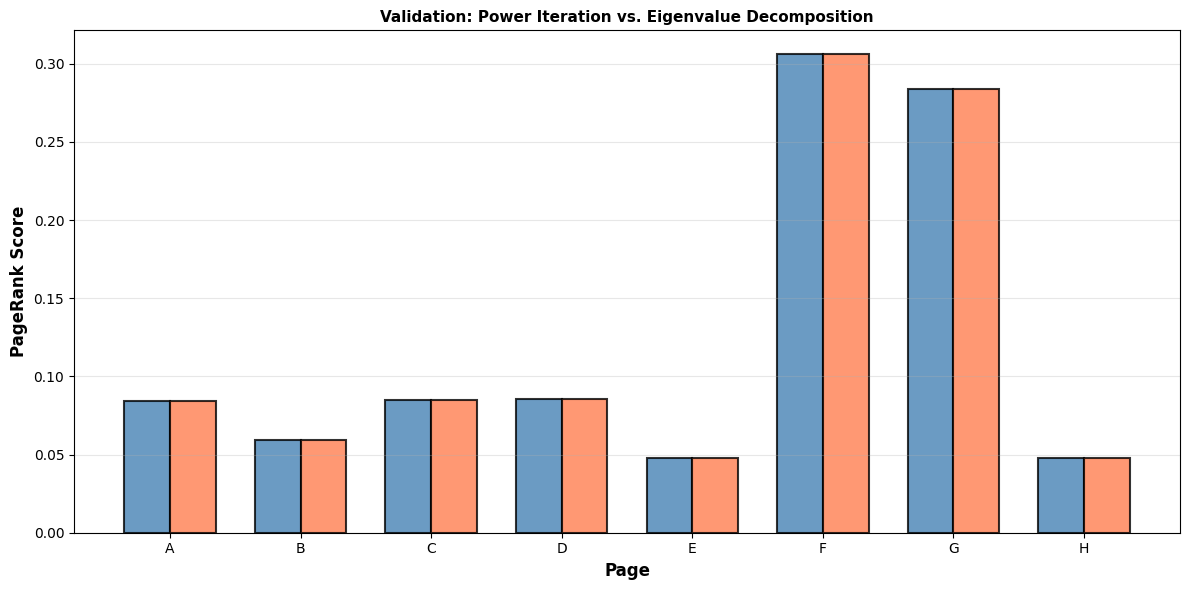

Damping factor d = 0.25 applied successfully
Converged in 9 with Final error = 8.25e-07

Validation Passed

Damping factor d = 0.5 applied successfully
Converged in 18 with Final error = 7.56e-07

Validation Passed

Damping factor d = 0.75 applied successfully
Converged in 43 with Final error = 8.02e-07

Validation Passed

Damping factor d = 0.85 applied successfully
Converged in 75 with Final error = 9.60e-07

Validation Passed

Damping factor d = 0.95 applied successfully
Did not converge in 100 iterations
Validation Passed


  d  | Iterations | Spider Trap (F+G) | Main Web (A-E)
------------------------------------------------------------
 0.25 |     100    |       29.5%      |      70.5%
 0.50 |     100    |       36.1%      |      63.9%
 0.75 |     100    |       48.7%      |      51.3%
 0.85 |     100    |       59.0%      |      41.0%
 0.95 |     100    |       79.3%      |      20.7%
------------------------------------------------------------


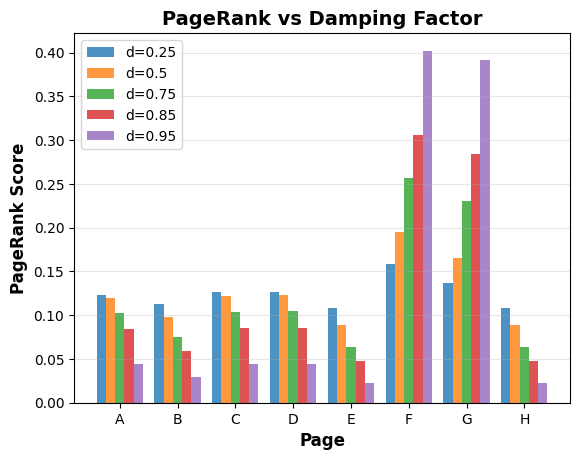

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pagerank_implementation import * 

# Section 4: Analysis & Experiments

In this section we will analyze the behaviour of the PageRank algorithm, validate the applied mathematical concepts, explore the actual aplication and test the robustness of the algorithm. To do so, we will perform four experiments as follows: 

1. Initial Vector Independence (Mathematical Foundation) - During this experiment we will demonstrate the strength of the PageRank algorithm - regardless of how the surfer starts its journey within the web, the pages score remains steady. We will test this by applying 3 different initial vectors, run Power Iteration from each starting point and verify that in all 3 cases result in the same final vector.
2. Personalized PageRank (Practical Application): in this experiment we are going to simulate personalized behaviour of the web surferer. We will consider that the surfer is biased and jumps towards specific pages. The question we will try to answer is how this personalized behavoir changes the page ranking to favor user interest? We will touch base the topic for applying user history and personalization for generating a page score.
3.  Network Connectivity (Structural Analysis): in this experiment we will investigate how sensitive is the network structure to changes and more specifically to removing links. Generally, the web structure determines the importance of the pages and their RangeRank score. We will show how the scores change and compare which pages are most affected when bridges between links are removed.
4.  Link Manipulation (vulnerability Testing)- in this last subsection we will demonstrate how adding artificial links in the web can boost a pages' ranking. This is the so called 'search engine optimization" attack and shows how vulnerable is PageRank to strategic and intentinal link manipulation.        

## Initial Vector Independence
This experiment aims to validate the main feature of the PageRank algorithm - the steady-state distribution of the scores is unique regardless of the starting point (initial probability distribution). [Refer to Perron-Frobenius Theorem]. We will execute the experiment by running the Power Iteration from 5 differnt starting points:

1. Uniform Distribution - all pages equally likely (already applied in the implementation phase Section 3)
2. Concentrated on Page A - all probability concentrated on one page.
3. 3 Random distributions - sampled from Dirichlet distribution [Refer to Dirichlet distribution why we choose it]

Doing the above 3 ponts we will show that the dominat eigenvector is unique for our primite stochastic matrices.

In [2]:
d = 0.85 #damping_factor

n = m_prime_web.shape[0] #erturns the number of pages in the web

v_uniform = np.ones(n) / n # the uniform distribution vector - default vector used in Section 3 

v_pageA = np.zeros(n) # personalized vector with 1x8 (n) zeros
v_pageA[0] = 1 # all probability goes to page A - we visit only page A

We are going to use the Power Iteration funciton to show that regardless of the input vector, the web scores will be equal to the eigenvalues.

In [3]:
def power_iteration_custom_vector(m_prime, v_initial, epsilon = 1e-6, max_iterations = 1000):
    x = v_initial.copy() # Just change the uniform distribution to personalized vector -> The rest is the same
    error_history = [] # Storage for convergence error tracking
    
    # Main iteration loop
    for iteration in range(max_iterations):
        x_new = m_prime @ x
        
        error = np.linalg.norm(x_new - x, ord=1)
        error_history.append(error)
        
        if error < epsilon: 
            print(f"Converged in {iteration + 1} with Final error = {error:.2e}\n")
            return x_new, error_history
        
        x = x_new # update vector
    
    print (f"Did not converge in {max_iterations} iterations")
    
    return x, error_history

In [4]:
r_uni, history_uni = power_iteration_custom_vector(m_prime_web, v_uniform)

r_pageA, history_pageA = power_iteration_custom_vector(m_prime_web, v_pageA)

Converged in 75 with Final error = 9.60e-07

Converged in 77 with Final error = 9.67e-07



In [5]:
print("Side-by-Side Comparison:")
print("-"*65)
print("Page | Uniform V  |  PageA V  |    EV    | Uni - EV | PageA - EV")
print("-"*65)
for i, label in enumerate(page_labels):
    diff_1 = abs(r_uni[i] - r_eig[i])
    diff_2 = abs(r_pageA[i] - r_eig[i])
    print(f"  {label}  |  {r_uni[i]:.6f}  |  {r_pageA[i]:.6f} | {r_pageA[i]:.6f} | {diff_1:.6f} | {diff_2:.6f}")


Side-by-Side Comparison:
-----------------------------------------------------------------
Page | Uniform V  |  PageA V  |    EV    | Uni - EV | PageA - EV
-----------------------------------------------------------------
  A  |  0.084104  |  0.084104 | 0.084104 | 0.000000 | 0.000000
  B  |  0.059595  |  0.059595 | 0.059595 | 0.000000 | 0.000000
  C  |  0.084924  |  0.084924 | 0.084924 | 0.000000 | 0.000000
  D  |  0.085272  |  0.085272 | 0.085272 | 0.000000 | 0.000000
  E  |  0.048012  |  0.048012 | 0.048012 | 0.000000 | 0.000000
  F  |  0.306071  |  0.306070 | 0.306070 | 0.000000 | 0.000000
  G  |  0.284011  |  0.284012 | 0.284012 | 0.000000 | 0.000000
  H  |  0.048012  |  0.048012 | 0.048012 | 0.000000 | 0.000000


Results Match - both starting vectors converge to the same steady-state of the PageRank scores. However, to further test the steady-state of the web scores, we will test with random probability distributions.

We sample from the Dirichlet distribution [add reference]:
  * Dirichlet $(\alpha_1, \dots, \alpha_n)$ generates random probability vectors
  * With $\alpha = [1, 1, \dots, 1]$, we get uniform distribution over the
    probability simplex Δⁿ (all valid probability distributions
    are equally likely)
  * This gives us arbitrary, unbiased random starting points

In [6]:
all_results = {
    'Uniform': (r_uni, history_uni),
    'Biased A': (r_pageA, history_pageA),
    'EigenValues': (r_eig,error)
} 

num_random = 3 # generate 3 random initial vectors

for i in range(num_random):
    alpha = np.ones(n)
    v_random = np.random.dirichlet(alpha)

    r_random, history_random = power_iteration_custom_vector(m_prime_web, v_random)

    label = f'Random_{i+1}'
    all_results[label] = (r_random, history_random)

Converged in 69 with Final error = 8.55e-07

Converged in 63 with Final error = 8.55e-07

Converged in 76 with Final error = 8.95e-07



In [7]:
r_reference = all_results['EigenValues'][0] # use for value comparision 

print("L1 Distance from Uniform Result:")
print("-"*30)
for label, (r, _) in all_results.items():
    if label == 'Uniform':
        continue
    # Compute L1 norm of difference
    distance = np.linalg.norm(r - r_reference, ord=1)
    
    print(f"  {label:18s}: {distance:.6f}")

L1 Distance from Uniform Result:
------------------------------
  Biased A          : 0.000000
  EigenValues       : 0.000000
  Random_1          : 0.000000
  Random_2          : 0.000000
  Random_3          : 0.000000


In [8]:
keys = list(all_results.keys())

print("P | EigenValues| Uniform   | Biased A  | Random V1 | Random V2 | Random V3  ")
print("-" * 80)

for i, label in enumerate(page_labels):
    row_values = [all_results[k][0][i] for k in keys]
    formatted_scores = " |".join(f"{val:10.6f}" for val in row_values)
    print(f"{label} | {formatted_scores}" )

P | EigenValues| Uniform   | Biased A  | Random V1 | Random V2 | Random V3  
--------------------------------------------------------------------------------
A |   0.084104 |  0.084104 |  0.084104 |  0.084104 |  0.084104 |  0.084104
B |   0.059595 |  0.059595 |  0.059595 |  0.059595 |  0.059595 |  0.059595
C |   0.084924 |  0.084924 |  0.084924 |  0.084924 |  0.084924 |  0.084924
D |   0.085272 |  0.085272 |  0.085272 |  0.085272 |  0.085272 |  0.085272
E |   0.048012 |  0.048012 |  0.048012 |  0.048012 |  0.048012 |  0.048012
F |   0.306071 |  0.306070 |  0.306071 |  0.306070 |  0.306070 |  0.306071
G |   0.284011 |  0.284012 |  0.284011 |  0.284012 |  0.284011 |  0.284011
H |   0.048012 |  0.048012 |  0.048012 |  0.048012 |  0.048012 |  0.048012


All 5 starting vectors (uniform, concentrated and 3 random vectors) converged to an identical steady-states. This  empirically validates the Perron-Frobenius theorem's guarantee that primitive stochastic matrices have a unique dominant eigenvector.The steady-state doesn't depend on initial conditions - it's a property of the GRAPH STRUCTURE (matrix M'), not our arbitrary starting assumptions (vector v₀). 

## Personalized PageRank

Currenly, for calculating the PageRank scores we apply the uniform distribution -  a random surfer jumps from pages to pages, so each webpage has "equal" probability to be visited. However, in reality, the surfer will visit the page that "favors" and the distribution is actually biased. We will represent this biased behaviour by modifiyng the transition matrix formula and including a personalization vector. We will test three types of "teleportations":

1. Standard ("uniform teleportation")
2. Personalized for Page A (always visit page A)
3. Personalized for Spider Trap F+G (favor those pages)

We will start with the standard PageRank computation where the surfer can jump to any page with equal probability - uniform distribution (1/n each). This was already done in the previous section, so we will show just the transformation matrix with applied damping effect and the resulted PageRank scores.

In [9]:
m_web #transition matrix without damping
m_prime_web #transition matrix with damping
r_web  #pagerank values
history_web #convergence history
r_eig #eigenvalues

print("\nPage | PageRank Score | Percentage")
print("-" * 42)
for label, score in zip(page_labels, r_web):
    print(f"  {label}  |    {score:.6f}    |   {score*100:.2f}%")
print("-" * 42)
print(f"Sum: {r_web.sum():.6f} (should be 1.0)")


Page | PageRank Score | Percentage
------------------------------------------
  A  |    0.084104    |   8.41%
  B  |    0.059595    |   5.96%
  C  |    0.084924    |   8.49%
  D  |    0.085272    |   8.53%
  E  |    0.048012    |   4.80%
  F  |    0.306071    |   30.61%
  G  |    0.284011    |   28.40%
  H  |    0.048012    |   4.80%
------------------------------------------
Sum: 1.000000 (should be 1.0)


The original formula we applied for calculating the transition matrix was: $M' = d \cdot M + \frac{1 - d}{n} \cdot E$ 

Now we are going to apply the modified formula [reference here]: $M' = d \cdot M + (1 - d) \cdot v_{personalized} \cdot 1^T$;

where  $v_{personalized}$ is the biased vector.

Now we are going to add the bias effect where the surfer prefers to jumps towars page A by applying a personalized initial vector where the probability of visiting page A is increased to 1.0 (100%) -> $[1,0,0 \dots ,0]$


In [10]:
d = 0.85 #damping_factor

transition_matrix = m_web.copy() #original transition matrix
n = transition_matrix.shape[0] #erturns the number of pages in the web

v_pageA = np.zeros(n) # personalized vector with 1x8 (n) zeros
v_pageA[0] = 1 # all probability goes to page A

personalization_matrix = np.zeros((n,n))
personalization_matrix[0,:] = np.ones(n) #all probability assigned to page A in the personalization matrix

In [11]:
personalization_matrix = np.outer(v_pageA,np.ones(n)) # we can use np.outer for more complicated personalized matrix - returning the outer product of two vectors - Matrix (n x n)

In [12]:
m_prime_pageA = d * transition_matrix + (1-d) * personalization_matrix
column_sums_pageA = m_prime_pageA.sum(axis = 0) 

print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_pageA}\n")
print(f"Sum of Columns: {column_sums_pageA} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.15   0.15   0.575  0.4333 0.15   0.15   0.15   0.2563]
 [0.425  0.     0.     0.     0.     0.     0.     0.1062]
 [0.425  0.425  0.     0.     0.     0.     0.     0.1062]
 [0.     0.425  0.425  0.     0.     0.     0.     0.1062]
 [0.     0.     0.     0.2833 0.     0.     0.     0.1062]
 [0.     0.     0.     0.     0.85   0.     0.85   0.1062]
 [0.     0.     0.     0.     0.     0.85   0.     0.1062]
 [0.     0.     0.     0.2833 0.     0.     0.     0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [13]:
#test with damping effect
transition_matrix = m_prime_web
n = transition_matrix.shape[0] #erturns the number of pages

v_pageA = np.zeros(n) # personalized vector
v_pageA[0] = 1 # all probability goes to page A

personalization_matrix = np.zeros((n,n))
personalization_matrix[0,:] = np.ones(n) #all probability assigned to page A in the personalization matrix

m_prime_pageA = d * transition_matrix + (1-d) * personalization_matrix
column_sums_pageA = m_prime_pageA.sum(axis = 0) 

print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_pageA}\n")
print(f"Sum of Columns: {column_sums_pageA} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.1659 0.1659 0.5272 0.4068 0.1659 0.1659 0.1659 0.2563]
 [0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.7384 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [14]:
#Define Personal Transition Matrix with Damping Effect 
def personal_transition_matrix (transition_matrix, personalization_vector, damping_factor = 0.85):
    n = transition_matrix.shape[0] #erturns the number of pages
    d = damping_factor

    personalization_matrix = np.outer(personalization_vector,np.ones(n)) #v_personalized * 1^T
    m_prime = d * transition_matrix + (1 - d) * personalization_matrix # apply modified scoring formula

    return m_prime

In [15]:
m_prime_pageA = personal_transition_matrix(m_prime_web,v_pageA)

In [16]:
print(f"Transition Matrix with biased behaviour\n")
print (f"{m_prime_pageA}\n")
print(f"Sum of Columns: {m_prime_pageA.sum(axis=0)} (should be 1.0 for all columns)")

Transition Matrix with biased behaviour

[[0.1659 0.1659 0.5272 0.4068 0.1659 0.1659 0.1659 0.2563]
 [0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.3772 0.3772 0.0159 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.7384 0.1062]
 [0.0159 0.0159 0.0159 0.0159 0.0159 0.7384 0.0159 0.1062]
 [0.0159 0.0159 0.0159 0.2568 0.0159 0.0159 0.0159 0.1062]]

Sum of Columns: [1. 1. 1. 1. 1. 1. 1. 1.] (should be 1.0 for all columns)


In [17]:
#Compare the Power Iteration and Eigenvector Score with the new transition matrix
r_web, history_web # PI Standard page scores
r_eig, error #Standard Eigenvector page scores

r_pi_pageA, history_pi_pageA = pagerank_power_iteration(m_prime_pageA,1e-6) # apply the personalized vector 

print("\nPage | Standard | Biased A  | Change_pi | Change_ev  ")
print("-"*50)
for i, label in enumerate(page_labels):
    change_pi = r_pi_pageA[i] - r_web[i]
    change_ev = r_pi_pageA[i] - r_eig[i]
    print(f"  {label}  | {r_eig[i]:.6f} | {r_pi_pageA[i]:.6f} | {change_pi:+.6f} | {change_ev:+.6f}")

Converged in 39 with Final error = 7.26e-07


Page | Standard | Biased A  | Change_pi | Change_ev  
--------------------------------------------------
  A  | 0.084104 | 0.253037 | +0.168933 | +0.168933
  B  | 0.059595 | 0.111692 | +0.052097 | +0.052097
  C  | 0.084924 | 0.152041 | +0.067118 | +0.067118
  D  | 0.085272 | 0.115556 | +0.030285 | +0.030285
  E  | 0.048012 | 0.048113 | +0.000101 | +0.000101
  F  | 0.306071 | 0.145814 | -0.160257 | -0.160257
  G  | 0.284011 | 0.125633 | -0.158378 | -0.158378
  H  | 0.048012 | 0.048113 | +0.000101 | +0.000101


In [18]:
r_ev_pageA = find_ev(m_prime_pageA) # apply the personalized transition matrix

print("\nPage | Standard | Biased A  | Change_pi | Change_ev  ")
print("-"*50)
for i, label in enumerate(page_labels):
    change_pi = r_ev_pageA[i] - r_web[i]
    change_ev = r_ev_pageA[i] - r_eig[i]
    print(f"  {label}  | {r_eig[i]:.6f} | {r_ev_pageA[i]:.6f} | {change_pi:+.6f} | {change_ev:+.6f}")


Page | Standard | Biased A  | Change_pi | Change_ev  
--------------------------------------------------
  A  | 0.084104 | 0.253037 | +0.168933 | +0.168933
  B  | 0.059595 | 0.111692 | +0.052097 | +0.052097
  C  | 0.084924 | 0.152041 | +0.067118 | +0.067118
  D  | 0.085272 | 0.115556 | +0.030285 | +0.030285
  E  | 0.048012 | 0.048113 | +0.000101 | +0.000101
  F  | 0.306071 | 0.145814 | -0.160257 | -0.160257
  G  | 0.284011 | 0.125633 | -0.158378 | -0.158378
  H  | 0.048012 | 0.048113 | +0.000101 | +0.000101


From the above comparison we can see that the biased behavior of the surfer actually changes significantly the PageRank score of pageA. While, initialy the page was mostly never visited, now its score significantly increasd with 17% due to the application of the surfer preferences. Another interesting result is that favoring page A is actually affecting the overall score of the main cluster of pages in the - from A to E while it takes scores from the spider trap F-G. If we turn this and favor the spider-trap then we will espect pages F and G to dominate the web, besides being isolated. The dangling node H is stable during the scenarios.     

In [19]:
#Test with Spider Trap Personalization
main_cluster = [0,1,2,3,4] #Main Pages A,B,C,D,E
spider_trap = [5,6] #F-G spider Trap

v_trap = np.zeros(n)

for i in spider_trap:
    v_trap[i] = 0.5 # Assing 50/50 probability to the pages in the spider trap F-G

m_prime_trap = personal_transition_matrix(m_web,v_trap)

r_trap = find_ev(m_prime_trap) 

In [20]:
sorted_indices_trap = np.argsort(r_trap)[::-1]  # Descending order
for rank, idx in enumerate(sorted_indices_trap, 1):
    label = page_labels[idx]
    score = r_trap[idx]
    print(f"  Rank {rank}: Page {label}  -  {score:.6f}  ({score * 100:.2f}%)")

  Rank 1: Page G  -  0.500000  (50.00%)
  Rank 2: Page F  -  0.500000  (50.00%)
  Rank 3: Page D  -  0.000000  (0.00%)
  Rank 4: Page A  -  0.000000  (0.00%)
  Rank 5: Page B  -  0.000000  (0.00%)
  Rank 6: Page C  -  0.000000  (0.00%)
  Rank 7: Page H  -  0.000000  (0.00%)
  Rank 8: Page E  -  0.000000  (0.00%)


In [21]:
#Standard vs Pers. A vs Pers. F+G
print("Page | Standard | Pers. A  | Trap F+G  |")
print("-"*40)
for i, label in enumerate(page_labels):  
    print(f"  {label}  | {r_eig[i]:.6f} | {r_ev_pageA[i]:.6f} | {r_trap[i]:.6f} | ")

Page | Standard | Pers. A  | Trap F+G  |
----------------------------------------
  A  | 0.084104 | 0.253037 | 0.000000 | 
  B  | 0.059595 | 0.111692 | 0.000000 | 
  C  | 0.084924 | 0.152041 | 0.000000 | 
  D  | 0.085272 | 0.115556 | 0.000000 | 
  E  | 0.048012 | 0.048113 | 0.000000 | 
  F  | 0.306071 | 0.145814 | 0.500000 | 
  G  | 0.284011 | 0.125633 | 0.500000 | 
  H  | 0.048012 | 0.048113 | 0.000000 | 


From the above experiments we can conclude: 

1. Personalization behaviour matters:
   * Biasing toward Page A increases its score by 17%.
   * Biasing toward F+G increases their combined score to 100% (50% for each page).
2. Score redistribution:
   * When the surfer favors Page A the main cluster (A-E) also gains higher scoring.
   * When the surfer favors F+G the spider trap dominates despite being isolated.
   * The dangling node H is relatively stable across scenarios.
3. Practical Applications:
   * Based on the users' browsing history, we can apply personalized search.
4. Mathematical insights:
   * Personal bias changes the dominant eigenvector.
   * Different teleportation = different steady-state.
   * Link structure still matters (authority still propagates).


## Network Connectivity
PageRank depends heavily on the web structure. Adjusting the links can isolate parts of the graph or affects "authority propagation". With this experiment hereby we will remove several critical links and observe the impact. Based on our current web structure we will do the following:

1. Remove the link D → E: This will remove the bridge from main cluster to the spider trap path. Observe how this isolation affects Page E's scoring. We expect the page E score to decrease when it is disconnected  
2. Remove the link C → A: This will create a cycle in main cluster within the graph.
3. Remove the link E → F: Remove the entry point to spider trap.

**Visual representation:**
```
        ┌──→ B ───→ D ──┐
        │    ↓      ↑   │
    A ──┤    C ─────┘   ├──→ E ──→ F ↔ G
        │    ↑          │      (spider trap)
        └────┘          │
                        └──→ H (dangling)

In [22]:
#Remove the link between D and E

A_modDE = A_web.copy()
A_modDE[4,3] = 0  

print(A_modDE)

[[0. 0. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]


In [23]:
m_mod_DE = build_transition_matrix(A_modDE) #build the transtion matrix
m_prime_mod_DE = add_damping(m_mod_DE) # Build the transition matrix with default damping effect
r_mod_DE = find_ev(m_prime_mod_DE)

Damping factor d = 0.85 applied successfully


In [24]:
print ("Page | Standard Web   | Modified Web | Change %  ")
print("-"*50)

for i, label in enumerate(page_labels):
    score_mod = r_mod_DE[i]
    score_std = r_eig[i]
    change = score_std - score_mod
    print(f"{label}    |    {score_std:6f}    |   {score_mod:6f}   | {change*100:.2f}")   

Page | Standard Web   | Modified Web | Change %  
--------------------------------------------------
A    |    0.084104    |   0.116452   | -3.23
B    |    0.059595    |   0.075741   | -1.61
C    |    0.084924    |   0.107931   | -2.30
D    |    0.085272    |   0.104310   | -1.90
E    |    0.048012    |   0.026249   | 2.18
F    |    0.306071    |   0.255398   | 5.07
G    |    0.284011    |   0.243337   | 4.07
H    |    0.048012    |   0.070581   | -2.26


From this small experiment we see the expected resutls that the scoring of page E decreases almost by almost 50% from 0.48 to 0.26. Hence, in case of network disruptions or network failures, the scoring will be adjsuted accordignly and pages without links will lose "importance".

Consequences of removing the bridge between D and E:
* Page E loses primary incoming link from main cluster
* Page E scoring drops significantly (becomes more dependent on teleportation)
* The impact on the main cluster (A-D) is minimal - they're robust

Next, we will check what will happen if we remove one more link which breaks the cycle of the main clusters in the web: Remove the link from C to A. 

In [25]:
#Remove the link from C to A
A_modCA = A_web.copy()
A_modCA[0,2] = 0
print(A_modCA)

[[0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]


In [26]:
m_mod_CA = build_transition_matrix(A_modCA) #build the transtion matrix
m_prime_mod_CA = add_damping(m_mod_CA) # Build the transition matrix with default damping effect
r_mod_CA = find_ev(m_prime_mod_CA)

Damping factor d = 0.85 applied successfully


In [27]:
#Lets examine the most affected pages from the link removal from C to A
changes_CA = np.abs(r_mod_CA - r_eig)

print (f"Most affected pages - Descending\n")
print (f"Page |Rank |   Old Score   |  New Score  | Change %")
print ("-"*60)
sorted_changes_mod = np.argsort(changes_CA)[::-1]  # Descending order
for i in (sorted_changes_mod):
    label = page_labels[i]
    old_score = r_eig[i]
    new_score = r_mod_CA[i]
    change = changes_CA[i]
    print(f" {label:^3} |{i+1:^5}|{old_score:^15.6f}|{new_score:^13.6f}|{change*100:^6.2f}% ")

Most affected pages - Descending

Page |Rank |   Old Score   |  New Score  | Change %
------------------------------------------------------------
  A  |  1  |   0.084104    |  0.053057   | 3.10 % 
  F  |  6  |   0.306071    |  0.325099   | 1.90 % 
  C  |  3  |   0.084924    |  0.066885   | 1.80 % 
  G  |  7  |   0.284011    |  0.300722   | 1.67 % 
  D  |  4  |   0.085272    |  0.101187   | 1.59 % 
  B  |  2  |   0.059595    |  0.046937   | 1.27 % 
  H  |  8  |   0.048012    |  0.053057   | 0.50 % 
  E  |  5  |   0.048012    |  0.053057   | 0.50 % 


In [28]:
# Now lets compare the page rankings of the 2 modified networks with the standard network
print ("Page |  Standard Web  |  Remove D->E  |  Remove C-> A")
print("-"*60)

for i, label in enumerate(page_labels):
    score_DE = r_mod_DE[i]
    score_std = r_eig[i]
    score_CA = r_mod_CA[i]
    print(f"{label:^5}|{score_std:^16.6f}|{score_DE:^16.6f}|{score_CA:^16.6f}") 

Page |  Standard Web  |  Remove D->E  |  Remove C-> A
------------------------------------------------------------
  A  |    0.084104    |    0.116452    |    0.053057    
  B  |    0.059595    |    0.075741    |    0.046937    
  C  |    0.084924    |    0.107931    |    0.066885    
  D  |    0.085272    |    0.104310    |    0.101187    
  E  |    0.048012    |    0.026249    |    0.053057    
  F  |    0.306071    |    0.255398    |    0.325099    
  G  |    0.284011    |    0.243337    |    0.300722    
  H  |    0.048012    |    0.070581    |    0.053057    


Removing the link from C to A creates a cycle in the main graph. This breaks the initial importance within the main cluster and now the scores are re-distributed in favor of page D. Yet, the effect is not so significant and most of the importance is still trapped within the spider cycle.     

In [29]:
##### Scenario 3 - Remove the link E → F: Remove the entry point to spider trap
A_modEF = A_web.copy()
A_modEF[5,4] = 0 # Remove the link from E to F
print(A_modEF)

[[0. 0. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]


In [30]:
m_mod_EF = build_transition_matrix(A_modEF) #build the transtion matrix
m_prime_mod_EF = add_damping(m_mod_EF) # Build the transition matrix with default damping effect
r_mod_EF = find_ev(m_prime_mod_EF)

Damping factor d = 0.85 applied successfully


In [31]:
changes_EF = np.abs(r_mod_EF - r_eig)

print (f"Most affected pages - Descending\n")
print (f"Page |Rank |   Old Score   |  New Score  | Change %")
print ("-"*45)
sorted_changes_mod = np.argsort(changes_EF)[::-1]  # Descending order
for i in (sorted_changes_mod):
    label = page_labels[i]
    old_score = r_eig[i]
    new_score = r_mod_EF[i]
    change = changes_EF[i]
    print(f" {label:^3} |{i+1:^5}|{old_score:^15.6f}|{new_score:^13.6f}|{change*100:^6.2f}% ")

Most affected pages - Descending

Page |Rank |   Old Score   |  New Score  | Change %
---------------------------------------------
  F  |  6  |   0.306071    |  0.218438   | 8.76 % 
  G  |  7  |   0.284011    |  0.218438   | 6.56 % 
  D  |  4  |   0.085272    |  0.117142   | 3.19 % 
  C  |  3  |   0.084924    |  0.116664   | 3.17 % 
  A  |  1  |   0.084104    |  0.115538   | 3.14 % 
  B  |  2  |   0.059595    |  0.081869   | 2.23 % 
  E  |  5  |   0.048012    |  0.065956   | 1.79 % 
  H  |  8  |   0.048012    |  0.065956   | 1.79 % 


In [32]:
print ("Page |  Standard Web  |  Remove D->E   |  Remove C-> A  |  Remove E-> F")
print("-"*70)

for i, label in enumerate(page_labels):
    score_DE = r_mod_DE[i]
    score_std = r_eig[i]
    score_CA = r_mod_CA[i]
    score_EF = r_mod_EF[i]
    print(f"{label:^5}|{score_std:^16.6f}|{score_DE:^16.6f}|{score_CA:^16.6f}|{score_EF:^16.6f}") 

Page |  Standard Web  |  Remove D->E   |  Remove C-> A  |  Remove E-> F
----------------------------------------------------------------------
  A  |    0.084104    |    0.116452    |    0.053057    |    0.115538    
  B  |    0.059595    |    0.075741    |    0.046937    |    0.081869    
  C  |    0.084924    |    0.107931    |    0.066885    |    0.116664    
  D  |    0.085272    |    0.104310    |    0.101187    |    0.117142    
  E  |    0.048012    |    0.026249    |    0.053057    |    0.065956    
  F  |    0.306071    |    0.255398    |    0.325099    |    0.218438    
  G  |    0.284011    |    0.243337    |    0.300722    |    0.218438    
  H  |    0.048012    |    0.070581    |    0.053057    |    0.065956    


Removing the connection between E and F completely isolates pages F and G from organic traffic. Their score decraease significantly from nearly 30% to 21.8% equally for both pages.The importance withi the network is redistributed towards the pages in the main cluster. Here we see that in cases of network changes the peripheral pages suffer the most.      

In [33]:
#Define a function for further tests
def find_ev_modified_remove (A_original, links_to_remove, damping_factor = 0.85):
    a_mod = A_original.copy()

    for (destination, origin) in links_to_remove:
        a_mod[origin,destination] = 0

    m_mod = build_transition_matrix(a_mod)
    m_prime_mod = add_damping(m_mod)
    r_mod = find_ev(m_prime_mod)

    return a_mod, r_mod

In [34]:
links_to_remove = [(4,5)]
a_mod2, r_mod2 =  find_ev_modified_remove(A_web, links_to_remove)

print(f"{r_mod2 == r_mod_EF}\n") #Quick check if the function is defined correctly - check with the scenario of removing link E -> F

print(a_mod2 == A_modEF)

Damping factor d = 0.85 applied successfully
[ True  True  True  True  True  True  True  True]

[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]


In [35]:
# Remove all three links simultaneously
links_to_remove_all = [(3, 4), (2, 0), (4, 5)]  # D→E, C→A, E→F

a_remove_all, r_remove_all = find_ev_modified_remove (A_web, links_to_remove_all)

Damping factor d = 0.85 applied successfully


In [36]:
# Find most affected pages
changes_all = np.abs(r_remove_all - r_eig)

print (f"Most affected pages - Descending\n")
print (f"Page |Rank |   Old Score   |  New Score  | Change %")
print ("-"*45)
sorted_changes_all = np.argsort(changes_all)[::-1]  # Descending order
for i in (sorted_changes_all):
    label = page_labels[i]
    old_score = r_eig[i]
    new_score = r_remove_all[i]
    change = changes_all[i]
    print(f" {label:^3} |{i+1:^5}|{old_score:^15.6f}|{new_score:^13.6f}|{change*100:^6.2f}% ")

Most affected pages - Descending

Page |Rank |   Old Score   |  New Score  | Change %
---------------------------------------------
  F  |  6  |   0.306071    |  0.217794   | 8.83 % 
  D  |  4  |   0.085272    |  0.154506   | 6.92 % 
  G  |  7  |   0.284011    |  0.217794   | 6.62 % 
  H  |  8  |   0.048012    |  0.098334   | 5.03 % 
  C  |  3  |   0.084924    |  0.106107   | 2.12 % 
  E  |  5  |   0.048012    |  0.032669   | 1.53 % 
  B  |  2  |   0.059595    |  0.074461   | 1.49 % 
  A  |  1  |   0.084104    |  0.098334   | 1.42 % 


In [37]:
print ("Page |  Standard Web  |  Remove D->E   |  Remove C-> A  |  Remove E-> F  |  Remove all")
print("-"*90)

for i, label in enumerate(page_labels):
    score_std = r_eig[i]
    score_DE = r_mod_DE[i]
    score_CA = r_mod_CA[i]
    score_EF = r_mod_EF[i]
    score_all = r_remove_all[i]
    print(f"{label:^5}|{score_std:^16.6f}|{score_DE:^16.6f}|{score_CA:^16.6f}|{score_EF:^16.6f}|{score_all:^16.6f}") 

Page |  Standard Web  |  Remove D->E   |  Remove C-> A  |  Remove E-> F  |  Remove all
------------------------------------------------------------------------------------------
  A  |    0.084104    |    0.116452    |    0.053057    |    0.115538    |    0.098334    
  B  |    0.059595    |    0.075741    |    0.046937    |    0.081869    |    0.074461    
  C  |    0.084924    |    0.107931    |    0.066885    |    0.116664    |    0.106107    
  D  |    0.085272    |    0.104310    |    0.101187    |    0.117142    |    0.154506    
  E  |    0.048012    |    0.026249    |    0.053057    |    0.065956    |    0.032669    
  F  |    0.306071    |    0.255398    |    0.325099    |    0.218438    |    0.217794    
  G  |    0.284011    |    0.243337    |    0.300722    |    0.218438    |    0.217794    
  H  |    0.048012    |    0.070581    |    0.053057    |    0.065956    |    0.098334    


In [38]:
all_results_remove = {
    'Standard': r_eig,
    'D->E': r_mod_DE,
    'C->A': r_mod_CA,
    'E->F': r_mod_EF,
    'Remove All': r_remove_all
}

In [39]:
all_results_remove

{'Standard': array([0.0841, 0.0596, 0.0849, 0.0853, 0.048 , 0.3061, 0.284 , 0.048 ]),
 'D->E': array([0.1165, 0.0757, 0.1079, 0.1043, 0.0262, 0.2554, 0.2433, 0.0706]),
 'C->A': array([0.0531, 0.0469, 0.0669, 0.1012, 0.0531, 0.3251, 0.3007, 0.0531]),
 'E->F': array([0.1155, 0.0819, 0.1167, 0.1171, 0.066 , 0.2184, 0.2184, 0.066 ]),
 'Remove All': array([0.0983, 0.0745, 0.1061, 0.1545, 0.0327, 0.2178, 0.2178, 0.0983])}

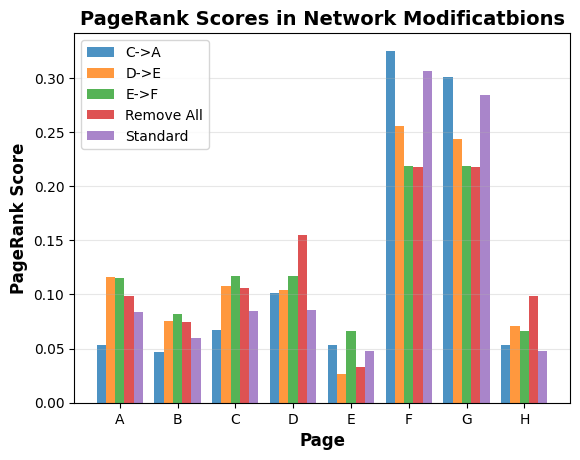

In [40]:
fig = plt.plot(figsize=(15, 6))
    
# Plot 1: PageRank scores comparison
rank_values = sorted(all_results_remove.keys())
x = np.arange(len(page_labels))
width = 0.8 / len(rank_values)
    
for i, d in enumerate(rank_values):
    r = all_results_remove[d]
    offset = (i - len(rank_values)/2) * width + width/2
    plt.bar(x + offset, r, width, label=f'{d}', alpha=0.8)
    
plt.xlabel('Page', fontsize=12, fontweight='bold')
plt.ylabel('PageRank Score', fontsize=12, fontweight='bold')
plt.title('PageRank Scores in Network Modificatbions', fontsize=14, fontweight='bold')
plt.xticks(x, page_labels)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [41]:
print("Page |  Standard Web  |  Remove D->E  |  Remove C-> A |  Remove E-> F |  Remove all")
print("-"*85)
for i, label in enumerate(page_labels):
    row_values = [all_results_remove[k][i] for k in all_results_remove.keys()]
    formatted_scores = " |".join(f"{val:14.6f}" for val in row_values)
    print(f"{label:<4} | {formatted_scores}" )

Page |  Standard Web  |  Remove D->E  |  Remove C-> A |  Remove E-> F |  Remove all
-------------------------------------------------------------------------------------
A    |       0.084104 |      0.116452 |      0.053057 |      0.115538 |      0.098334
B    |       0.059595 |      0.075741 |      0.046937 |      0.081869 |      0.074461
C    |       0.084924 |      0.107931 |      0.066885 |      0.116664 |      0.106107
D    |       0.085272 |      0.104310 |      0.101187 |      0.117142 |      0.154506
E    |       0.048012 |      0.026249 |      0.053057 |      0.065956 |      0.032669
F    |       0.306071 |      0.255398 |      0.325099 |      0.218438 |      0.217794
G    |       0.284011 |      0.243337 |      0.300722 |      0.218438 |      0.217794
H    |       0.048012 |      0.070581 |      0.053057 |      0.065956 |      0.098334


When removing all three links then we can see that the graph becomes more fragmented into smaller components and the authority spread more uniformaly. Even the dangling page H doubles its score to almost 10%. The spider trap pages still have the higest scores but are completely isolated and their importance drop by one-third to slightly above 21%. In this way the damping factor becomes more important while the authority is moved within the main cluster.

From the above experiments we can conlcude that the main cluster is structually resilient. While deleting links to and out of the main cluster and creating cycle in it, these actions does not affect the page score signifincantly compared to the score of page F and G. The peripheral nodes suffer the most from getting isolated and are the most vulnerable to link losses. From the experiments we also see that the damping factor prevents the total isolation of pages (node H), so each page will always have some initial scoring.            

## Link Manipulation
Lastly, we will investigate how strong is the PageRank algorithm against manipulation "attacks". Websites' Owners can try to artificially improve their scores creating fake links pointing to their site, getting links from pages with high scores or use other linking schemes. Generally, the PageRank algorithm relies heavily on the graph structure and its connectivity. So, in this experiment we will simulate an attacker who tries to boost Page # score (low score) through strategic link addition. We will perform the below experiments simulating such behaviour: 

1. Getting links from highly scored pages: add link from Page F (the page with the highest score) to Page H (the dangling node with only one link to page D).
3. Creating Fake Link Farms: add links from pages A, B and C (multiple pages from the main cluster) to page H - including the dangling node to the main web cluster.
4. Reduce link importance: We will test if lower lower damping factor actually minimizes the effect of link manipulations investigated in p.1 and p.2. We will test  three values for the damping factor: d = [0.85; 0.50; 0.25]. We expect that with higher teleportation effect (lower d), manipulated links will have less impact. Rankings are expected to be more uniform and respectively  harder to manipulate.

In [42]:
#experiment 1 - Add link from page F to page H
A_mod_FH = A_web.copy()
A_mod_FH[7,5] = 1 #

print (A_mod_FH)

[[0. 0. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0.]]


In [43]:
m_mod_FH = build_transition_matrix(A_mod_FH)

In [44]:
m_prime_FH = add_damping(m_mod_FH) # add damping effect

Damping factor d = 0.85 applied successfully


In [45]:
r_mod_FH = find_ev(m_prime_FH)

In [46]:
changes_FH = np.abs(r_mod_FH - r_eig) # Full Ranking Comparison

print (f"Most affected pages - Descending\n")
print (f"Page |Rank |   Old Score   |  New Score  | Change %")
print ("-"*50)
sorted_changes_mod = np.argsort(changes_FH)[::-1]  # Descending order
for i in (sorted_changes_mod):
    label = page_labels[i]
    old_score = r_eig[i]
    new_score = r_mod_FH[i]
    change = changes_FH[i]
    print(f" {label:^3} |{i+1:^5}|{old_score:^15.6f}|{new_score:^13.6f}|{change*100:^6.2f}% ")

Most affected pages - Descending

Page |Rank |   Old Score   |  New Score  | Change %
--------------------------------------------------
  G  |  7  |   0.284011    |  0.118223   |16.58 % 
  F  |  6  |   0.306071    |  0.195612   |11.05 % 
  H  |  8  |   0.048012    |  0.153765   |10.58 % 
  D  |  4  |   0.085272    |  0.125443   | 4.02 % 
  C  |  3  |   0.084924    |  0.124931   | 4.00 % 
  A  |  1  |   0.084104    |  0.123725   | 3.96 % 
  B  |  2  |   0.059595    |  0.087671   | 2.81 % 
  E  |  5  |   0.048012    |  0.070630   | 2.26 % 


From this quick test we can see that page H has the higest positive change in score within the complete graph going from 4.8%  to nearly 10.6%. This is more than 100% increase of the score. As expected, the importance was "taken" from the spider-trap pages F and G whose score decreased by over 11% and 16% respectively. This once more indicates how much the PageRank algorithm is vulnerable to link manipulations.     

In [47]:
#Experiment 2: add many links to a single page
A_mod_many = A_web.copy()

links_to_add = ([0,7],[1,7],[2,7])

for (origin, destination) in links_to_add:
    A_mod_many[destination,origin] = 1

print(A_mod_many)

[[0. 0. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]]


In [48]:
m_mod_many = build_transition_matrix(A_mod_many)
m_prime_many = add_damping (m_mod_many)
r_mod_many = find_ev(m_prime_many)

Damping factor d = 0.85 applied successfully


In [49]:
changes_many = np.abs(r_mod_many - r_eig) # Full Ranking Comparison

print (f"Most affected pages - Descending\n")
print (f"Page |Rank |   Old Score   |  New Score  | Change %")
print ("-"*50)
sorted_changes_mod = np.argsort(changes_many)[::-1]  # Descending order
for i in (sorted_changes_mod):
    label = page_labels[i]
    old_score = r_eig[i]
    new_score = r_mod_many[i]
    change = changes_many[i]
    print(f" {label:^3} |{i+1:^5}|{old_score:^15.6f}|{new_score:^13.6f}|{change*100:^6.2f}% ")

Most affected pages - Descending

Page |Rank |   Old Score   |  New Score  | Change %
--------------------------------------------------
  H  |  8  |   0.048012    |  0.092499   | 4.45 % 
  D  |  4  |   0.085272    |  0.058412   | 2.69 % 
  C  |  3  |   0.084924    |  0.059181   | 2.57 % 
  G  |  7  |   0.284011    |  0.308016   | 2.40 % 
  F  |  6  |   0.306071    |  0.328751   | 2.27 % 
  A  |  1  |   0.084104    |  0.061896   | 2.22 % 
  B  |  2  |   0.059595    |  0.046115   | 1.35 % 
  E  |  5  |   0.048012    |  0.045128   | 0.29 % 


In this scenario, page H again is observed to have the highest increase in score going nearly double from 4.8% to 9.2%. However, this time the authority in the web was not shifterd from the spider-trap pages F and G but from the main cluster pages A,B,C and D. All of those "main-cluster" pages experienced a decrease in score since page H is now a member of this cluster and the authority is re-distributed across more pages. The two pages with the highest scores from the cluster page D and page C contributes the most to the new score of page H.   

In [50]:
def find_ev_modified_add (A_original, links_to_add, damping_factor = 0.85):
    a_mod = A_original.copy()

    for (destination, origin) in links_to_add:
        a_mod[origin,destination] = 1

    m_mod = build_transition_matrix(a_mod)
    m_prime_mod = add_damping(m_mod,damping_factor)
    r_mod = find_ev(m_prime_mod)

    return a_mod, r_mod

In [51]:
#quick check on the function definition 
links_to_add = ([0,7],[1,7],[2,7])
a_mod3, r_mod3 =  find_ev_modified_add(A_web, links_to_add)

print(f"{r_mod3 == r_mod_many}\n") #Quick check if the function is defined correctly - check with the scenario of removing link E -> F

print(a_mod3 == A_mod_many)


Damping factor d = 0.85 applied successfully
[ True  True  True  True  True  True  True  True]

[[ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]


In [52]:
#Experiment 3: Test Damping Effect influence on link manipulation
damping_effects = [0.25, 0.50, 0.85]
results_de = {}

links_to_add = ([0,7],[1,7],[2,7])

for d in damping_effects:
    a_mod_d,r_mod_d = find_ev_modified_add(A_web, links_to_add, d)
    results_de[d] = [r_mod_d,a_mod_d]

Damping factor d = 0.25 applied successfully
Damping factor d = 0.5 applied successfully
Damping factor d = 0.85 applied successfully


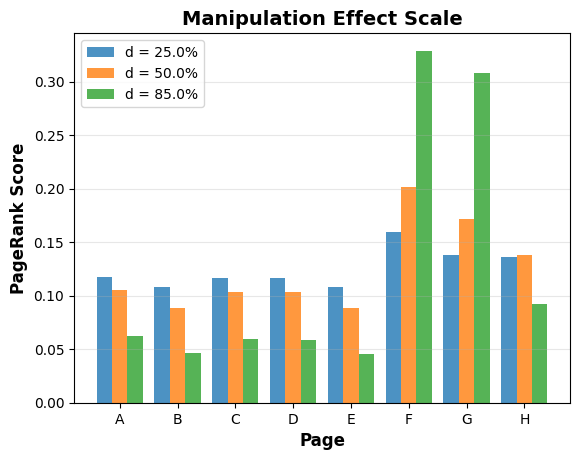

In [53]:
fig = plt.plot(figsize=(15, 6))
    
# Plot 1: PageRank scores comparison
rank_values = sorted(results_de.keys())
x = np.arange(len(page_labels))
width = 0.8 / len(rank_values)
    
for i, d in enumerate(rank_values):
    r, _ = results_de[d]
    offset = (i - len(rank_values)/2) * width + width/2
    plt.bar(x + offset, r, width, label=f'd = {d*100:.1f}%', alpha=0.8)
    
plt.xlabel('Page', fontsize=12, fontweight='bold')
plt.ylabel('PageRank Score', fontsize=12, fontweight='bold')
plt.title('Manipulation Effect Scale', fontsize=14, fontweight='bold')
plt.xticks(x, page_labels)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [54]:
print("\nPage |    25%     |    50%    |    85%")
print("-"*50)
for i, label in enumerate(page_labels):
    row_values = [results_de[k][0][i] for k in results_de.keys()]
    formatted_scores = " |".join(f"{val:10.6f}" for val in row_values)
    print(f"{label:<4} | {formatted_scores}" )


Page |    25%     |    50%    |    85%
--------------------------------------------------
A    |   0.117466 |  0.105565 |  0.061896
B    |   0.107796 |  0.088716 |  0.046115
C    |   0.116779 |  0.103502 |  0.059181
D    |   0.116722 |  0.103158 |  0.058412
E    |   0.107734 |  0.088315 |  0.045128
F    |   0.159406 |  0.201119 |  0.328751
G    |   0.137859 |  0.171681 |  0.308016
H    |   0.136238 |  0.137945 |  0.092499


As we can see from the above graph and table, the lower the damping factor is the page rankings become more uniform. With lower damping factor the manipulations are less effective, but then we assume that the surferer teleportations more through the pages. This might seem as good approach to minimize the manipulations but then we will ignore the real importance of one page over another.

Generally, from this experiment we can conclude that the original PageRank algorithm is vulnerable to link manipulations and needs additional improvements. That is why Google does not rely only on the PageRank algorithm and it applies more methods for scoring and page filtering. 

Write conclusion and summary: 

Overall, we did 4 experiments to validate the PageRank mathematical properties, explore its applications and test the algorithm robustness on a web graph with 8 pages. 

Initial Vector Independence. 

The Pesronalized PageRank experiment showed us that teleportantion towards specific rankings actually changes its scoring. Applying personalized vector which represents surfers preferences towards a page we actually showed the need of personalized page scores.

Network Connectivity 

Link Manipulation

